In [1]:
import numpy as np
import wfdb


records = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
           '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
           '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
           '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
           '222', '223', '228', '230', '231', '232', '233', '234']

valid_types = ['A', 'E', 'F', 'J', 'L', 'N', 'Q', 'R', 'S', 'V', 'a', 'e', 'f', 'j', 'x']

X = []
y = []

window = int(0.5 * 360)


for rec in records:

    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    annotation = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    signal = record.p_signal[:, 0]

    for i, r in enumerate(annotation.sample):
        if r - window < 0 or r + window > len(signal):
            continue
        segment = signal[r - window : r + window]
        label = annotation.symbol[i]
        if label in valid_types:
            X.append(segment)
            y.append(label)

X = np.array(X)
y = np.array(y)
print(X.shape, y.shape)

(102608, 360) (102608,)


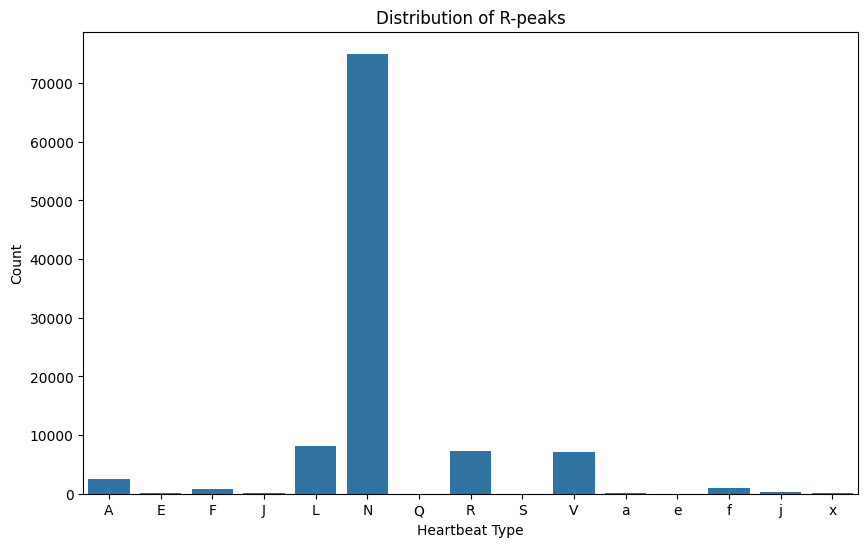

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x=y, order=np.unique(y))
plt.title('Distribution of R-peaks')
plt.xlabel('Heartbeat Type')
plt.ylabel('Count')
plt.show()

In [3]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(np.unique(y))

['A' 'E' 'F' 'J' 'L' 'N' 'Q' 'R' 'S' 'V' 'a' 'e' 'f' 'j' 'x']


In [4]:
print(np.unique(y_encoded))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [6]:
!pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 25.8 MB/s  0:00:00

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


/Users/nischithajayaraj/miniconda3/lib/python3.11/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 7 is too high: all coefficients will experience boundary effects.
  warnings.warn(


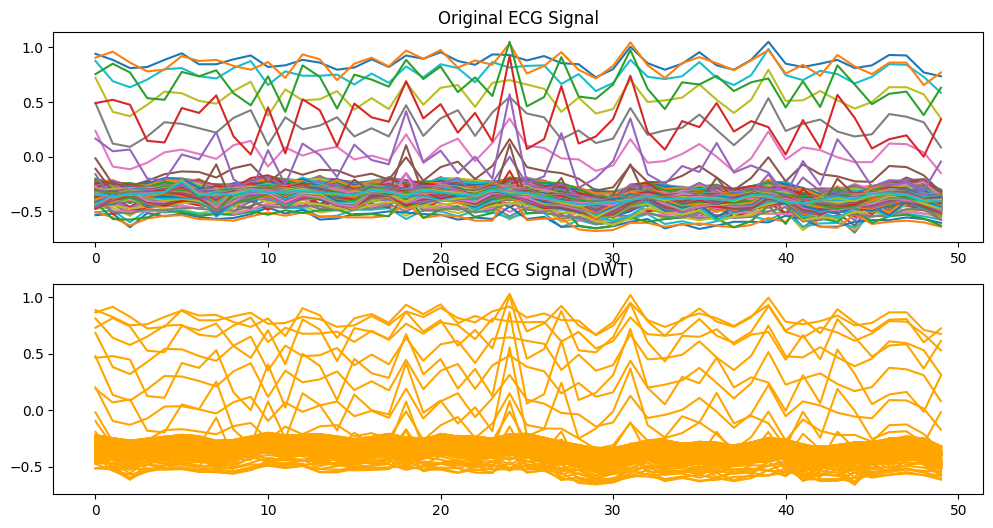

8


In [7]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

wavelet = 'db4'
levels = 7

# Decomposes X into cA4 and cD4-cD1; separates signal into frequency bands, with noice typically in high-frequency cD1-cD4
coeffs = pywt.wavedec(X, wavelet, level=levels)

# Estimates noise standrd deviation to set the thresholding level
sigma = np.median(np.abs(coeffs[-1])) / 0.6745

# Determines cutoff for suppressing noise in detail coefficients
thresold = sigma * np.sqrt(2 * np.log(len(X)))

# Applies soft thresholding to detail coefficients (cD4-cD1); removes noise (small coefficients) while preserving signal features
coeffs_threshold = [coeffs[0]] + [pywt.threshold(c, thresold, mode='soft') for c in coeffs[1:]]

denoised_X = pywt.waverec(coeffs_threshold, wavelet)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(X[:50], label='Original')
plt.title('Original ECG Signal')

plt.subplot(2, 1, 2)
plt.plot(denoised_X[:50], label='Denoised', color='orange')
plt.title('Denoised ECG Signal (DWT)')

plt.show()

print(len(coeffs))

In [9]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [10]:
from collections import Counter
import random
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Initial distribution
print("Initial class distribution:", Counter(y_encoded))

# Filter classes with at least 3 samples
valid_classes = [cls for cls, count in Counter(y_encoded).items() if count >= 3]
valid_mask = [label in valid_classes for label in y_encoded]
X_filtered, y_filtered = X[valid_mask], y_encoded[valid_mask]

# SMOTE: Reshape to 2D (samples, features) for SMOTE
n_samples = X_filtered.shape[0]  # Should be ~102606
X_2d = X_filtered.reshape(n_samples, -1)  # Shape: (n_samples, 360)

# Apply SMOTE
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_2d, y_filtered)
X_smote = X_smote.reshape(-1, 360, 1)  # Reshape back to (samples, 360, 1)

# Undersample Normal class (assuming 'N' is label 5)
normal_mask = y_smote == list(le.classes_).index('N')
normal_indices = random.sample(list(np.where(normal_mask)[0]), min(50000, sum(normal_mask)))
final_indices = normal_indices + list(np.where(~normal_mask)[0])

# Final balanced dataset
X_balanced, y_balanced = X_smote[final_indices], y_smote[final_indices]

# Train/val/test split (60-20-20)
X_train, X_val, y_train, y_val = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print("Final distributions:")
print(f"Train: {Counter(y_train)}\nVal: {Counter(y_val)}\nTest: {Counter(y_test)}")

Initial class distribution: Counter({np.int64(5): 75011, np.int64(4): 8071, np.int64(7): 7255, np.int64(9): 7129, np.int64(0): 2546, np.int64(12): 982, np.int64(2): 802, np.int64(13): 229, np.int64(14): 193, np.int64(10): 150, np.int64(1): 106, np.int64(3): 83, np.int64(6): 33, np.int64(11): 16, np.int64(8): 2})
Final distributions:
Train: Counter({np.int64(9): 45007, np.int64(2): 45007, np.int64(1): 45007, np.int64(4): 45007, np.int64(13): 45007, np.int64(0): 45007, np.int64(14): 45007, np.int64(6): 45006, np.int64(7): 45006, np.int64(10): 45006, np.int64(12): 45006, np.int64(3): 45006, np.int64(11): 45006, np.int64(5): 30000})
Val: Counter({np.int64(12): 15003, np.int64(3): 15003, np.int64(7): 15003, np.int64(10): 15002, np.int64(14): 15002, np.int64(9): 15002, np.int64(0): 15002, np.int64(4): 15002, np.int64(11): 15002, np.int64(1): 15002, np.int64(13): 15002, np.int64(2): 15002, np.int64(6): 15002, np.int64(5): 10000})
Test: Counter({np.int64(6): 15003, np.int64(11): 15003, np.int6

In [12]:
!pip install tensorflow


  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached rich-14.2.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 MB 16.2 MB/s  0:00:12 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.4/667.4 kB 18.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 21.4 MB/s  0:00:005.6 MB/s eta 0:00:01
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 18.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5

In [13]:
import tensorflow as tf

# Build ANN
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(360,)),  # Layer 1
    tf.keras.layers.Dense(32, activation='relu'),                    # Layer 2
    tf.keras.layers.Dense(64, activation='relu'),                    # Layer 3
    tf.keras.layers.Dense(15, activation='softmax')          # Output layer
])

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Accuracy: {accuracy}")

/Users/nischithajayaraj/miniconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
19222/19222 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - accuracy: 0.9367 - loss: 0.2203 - val_accuracy: 0.9706 - val_loss: 0.0984
Epoch 2/50
19222/19222 ━━━━━━━━━━━━━━━━━━━━ 11s 595us/step - accuracy: 0.9740 - loss: 0.0871 - val_accuracy: 0.9813 - val_loss: 0.0649
Epoch 3/50
19222/19222 ━━━━━━━━━━━━━━━━━━━━ 17s 870us/step - accuracy: 0.9802 - loss: 0.0661 - val_accuracy: 0.9850 - val_loss: 0.0492
Epoch 4/50
19222/19222 ━━━━━━━━━━━━━━━━━━━━ 14s 713us/step - accuracy: 0.9836 - loss: 0.0553 - val_accuracy: 0.9867 - val_loss: 0.0443
Epoch 5/50
19222/19222 ━━━━━━━━━━━━━━━━━━━━ 11s 574us/step - accuracy: 0.9854 - loss: 0.0497 - val_accuracy: 0.9816 - val_loss: 0.0572
Epoch 6/50
19222/19222 ━━━━━━━━━━━━━━━━━━━━ 11s 590us/step - accuracy: 0.9870 - loss: 0.0442 - val_accuracy: 0.9891 - val_loss: 0.0380
Epoch 7/50
19222/19222 ━━━━━━━━━━━━━━━━━━━━ 11s 588us/step - accuracy: 0.9876 - loss: 0.0415 - val_accuracy: 0.9879 - val_loss: 0.0389
Epoch 8/50
19222/19222 ━━━━━━━━━━━━━━━━━━━━ 12s 601us/ste